# 5 - Neo-Riemannian Transformations

## Imports

In [254]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [292]:
import pandas as pd
from fractions import Fraction
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm
import music21 as m21
import re

import sys
sys.path.append('/Users/Jessica/Documents/ERIP2025/Jessica-ERIP2025/')

from Importables import General as g
from Importables import intervalanalysis_utils as ia
from Importables import tonnetz_utils as t

In [258]:
metadata = g.load_metadata()

## Test: One piece

In [ ]:
test = metadata[metadata['fnames'] == 'Final Thought - Kamasi Washington']
labels = g.load_labels(test)
labels.head() 

In [ ]:
transformations, exceptions = t.transformation(labels)
transformations.value_counts(subset=['transformation']).reset_index(name='count')

## All Labels

In [260]:
labels = g.load_labels(metadata)
transformations, exceptions = t.transformation(labels) 

nan,Cheepnis


In [262]:
transformations_cut = transformations[transformations['transformation'] != 'N/A'].copy()

In [264]:
transformations.value_counts(subset=['transformation']).reset_index(name='count') 

,transformation,count
0,N/A,11979
1,RL,4626
2,N,2972
3,P,830
4,RP,393
5,R,373
6,H,291
7,PR,224
8,PP,211
9,L,202


### N/A Transformations

For NA pairs that are both major/minor, look for two transformations and make new categories for them

In [266]:
NA = transformations[transformations['transformation'] == 'N/A'].copy()
print(NA.shape[0])
NA.value_counts(subset=['chord_1', 'chord_2']).reset_index(name='count').head(15) 

11979


,chord_1,chord_2,count
0,Cm7,F7,691
1,Gm7,C7,615
2,Fm7,B-7,537
3,Dm7,G7,472
4,Am7,D7,377
5,B-m7,E-7,364
6,Em7b5,A7b9,201
7,Am7b5,D7b9,198
8,E-m7,A-7,181
9,Em7,A7,179


### Exceptions

In [269]:
exceptions_count = labels[labels['label'].isin(exceptions)].value_counts(subset=['label']).reset_index(name='count')
exceptions_count.head(10)

,label,count
0,Cm69,134
1,E13no3,27
2,F13no3,27
3,E-13no3,15
4,G#dim,14
5,D13sus4,13
6,Edim,11
7,Do,8
8,A-9sus4,6
9,D-M7no5,6


### Group by year

In [297]:
bins = np.arange(1950, 2030, 10) 
bin_labels = [f"{start}-{start+10}" for start in bins[:-1]]

In [299]:
# Bin years
transformations['year_bin'] = pd.cut(transformations['recording_year'], bins=bins, labels=bin_labels, right=False)
transformations = transformations[transformations['year_bin'].notna()].copy()

transformations_cut['year_bin'] = pd.cut(transformations_cut['recording_year'], bins=bins, labels=bin_labels, right=False)
transformations_cut = transformations_cut[transformations_cut['year_bin'].notna()].copy()

<function matplotlib.pyplot.show(close=None, block=None)>

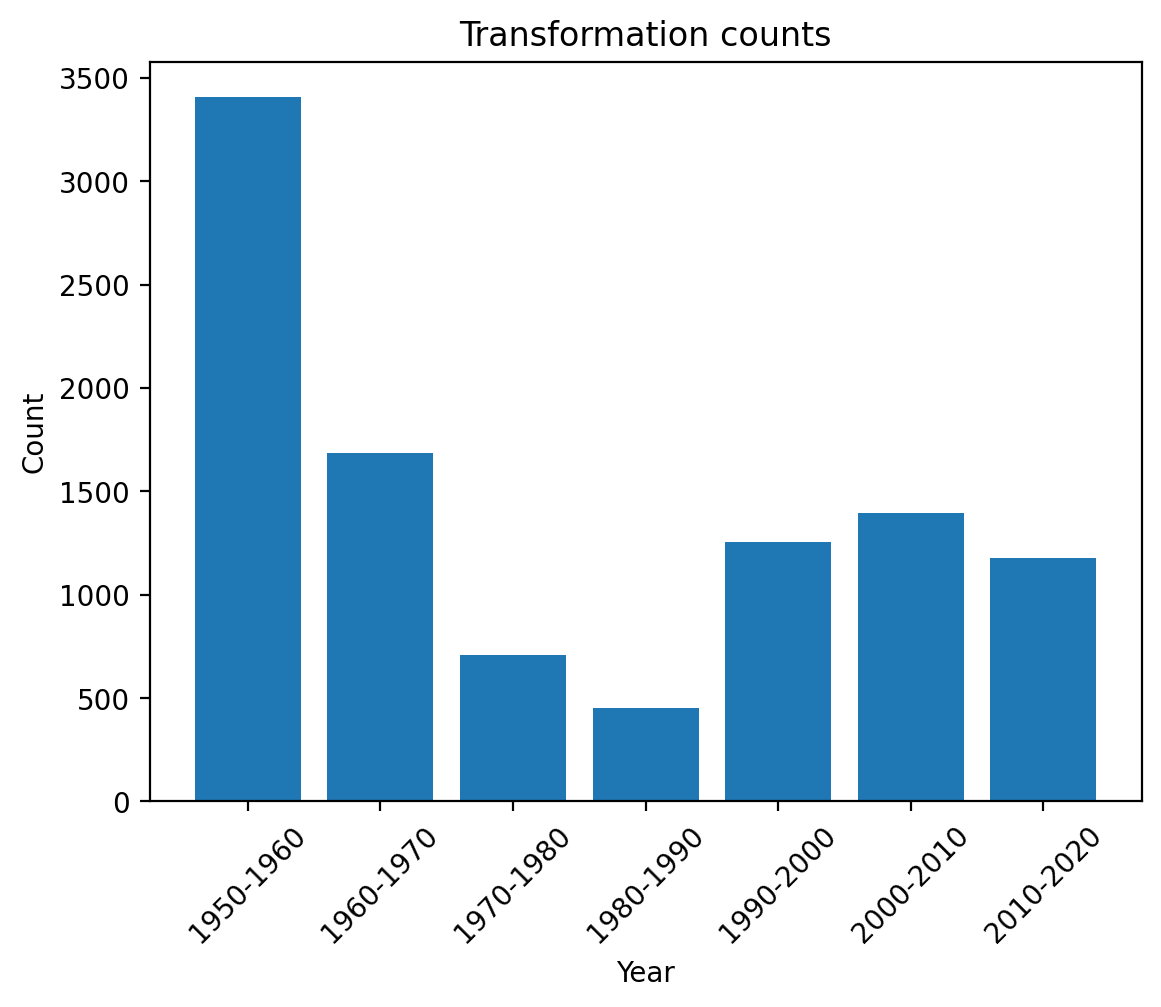

In [278]:
transformations_cut['year_bin'] = pd.Categorical(transformations_cut['year_bin'], categories=bin_labels, ordered=True)
counts = transformations_cut.value_counts(subset=['year_bin']).reset_index(name='count')
counts = counts.sort_values('year_bin')
y = counts['count']
x = counts['year_bin']
plt.bar(x, y)
plt.title('Transformation counts')
plt.ylabel('Count')
plt.xlabel('Year')
plt.xticks(x,rotation=45)
plt.savefig(f"../Results/JazzTransformationsCounts")
plt.show


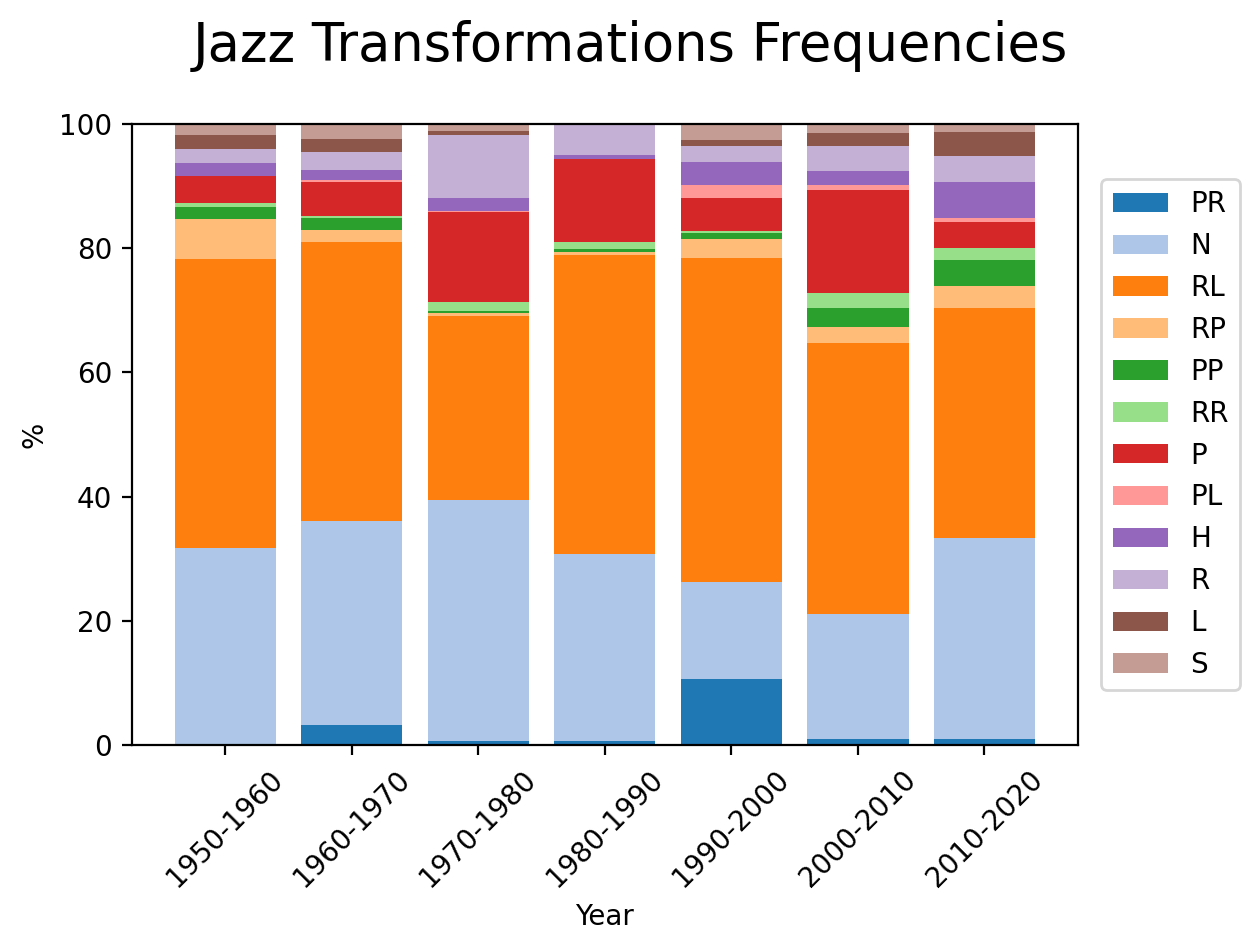

In [310]:
df_plot = transformations_cut.copy()
fig, ax = t.bar_plot_transformation(df_plot)
plt.tight_layout()
#plt.savefig(f"../Results/JazzTransformations")
plt.show()

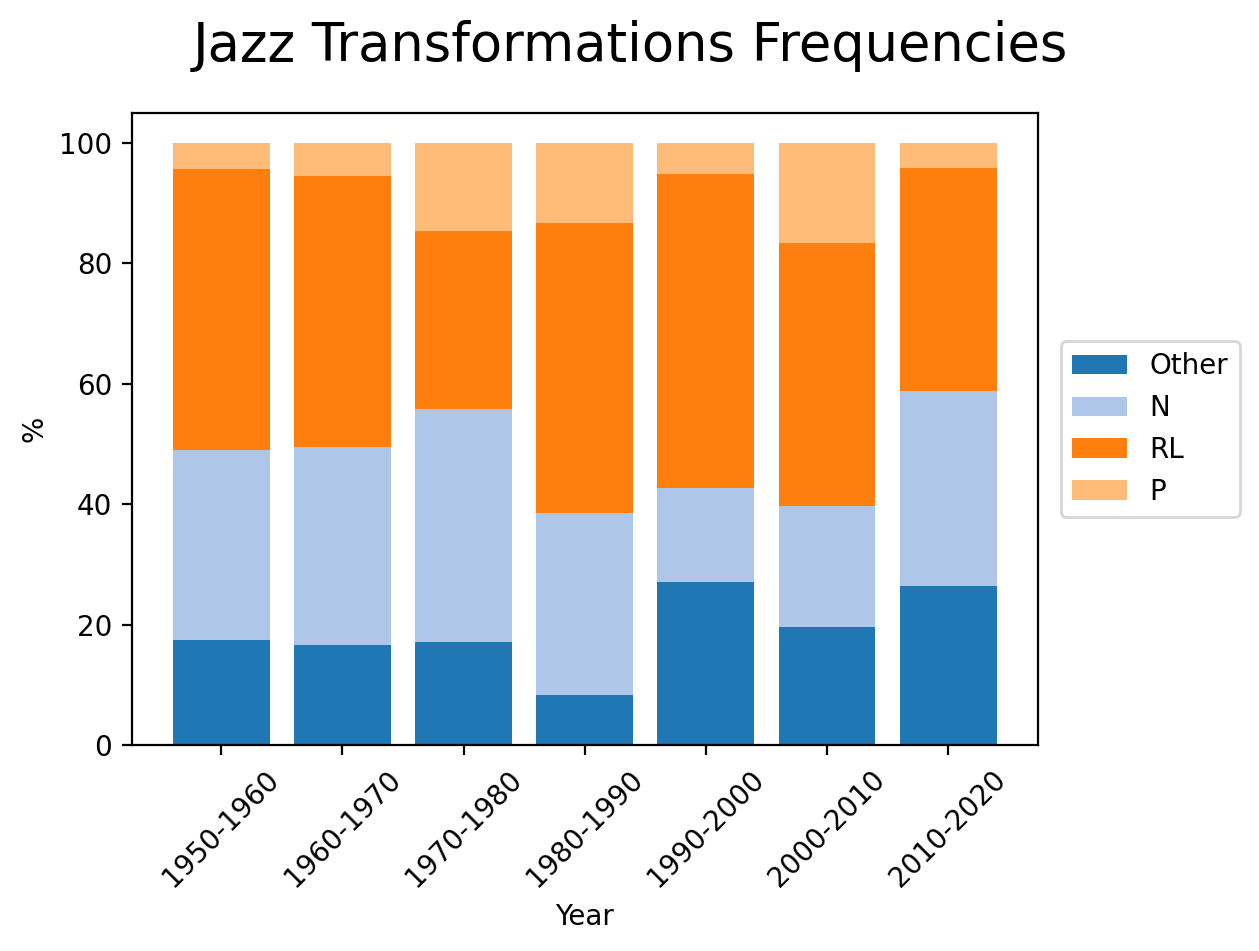

In [314]:
keep = ['N', 'RL', 'P']

df_plot = transformations_cut.copy()
df_plot['transformation'] = df_plot['transformation'].where(
    df_plot['transformation'].isin(keep),
    'Other'
)

fig, ax = t.bar_plot_transformation(df_plot)
plt.tight_layout()
plt.show()

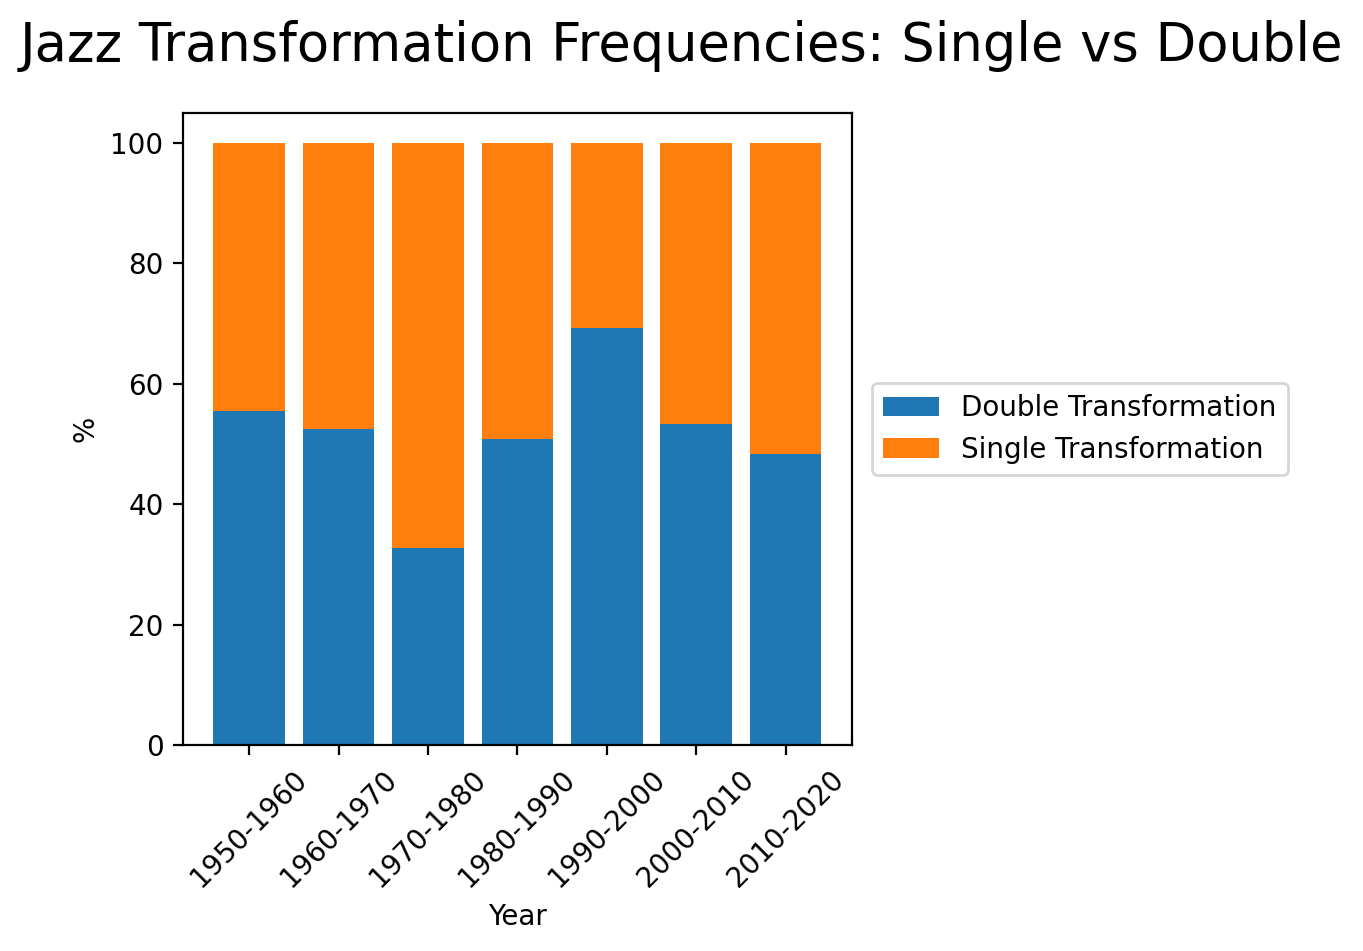

In [316]:
transformations_two = transformations_cut.copy()
transformations_two['transformation'] = transformations_two['transformation'].apply(
    lambda t: 'Double Transformation' if len(t) == 2 else 'Single Transformation'
)

x = year_bins
num_bins = len(x)

fig, ax = plt.subplots()
current_itn = np.zeros(num_bins)
counts = transformations_two.value_counts(subset=['year_bin']).reset_index(name='count')
counts = counts.sort_values('year_bin')
tot_counts = (
    transformations_two.groupby('year_bin')
    .size()
    .reindex(x, fill_value=0)
)

for trans in transformations_two.value_counts(subset=['transformation']).reset_index(name='count')['transformation']:
    transformation_subset = transformations_two[transformations_two['transformation']== trans]
    transformations_subset_grouped = (
        transformation_subset.groupby('year_bin')
        .size()
        .reindex(x, fill_value=0)
        .reset_index(name='count')
    )
    
    y = transformations_subset_grouped['count'] 
    y = np.array(y) * 100/tot_counts

    ax.bar(x, y, bottom = current_itn, label=trans)

    current_itn = current_itn + y

    ax.set_xticks(np.arange(num_bins))
    ax.set_xlabel('Year')
    ax.set_ylabel('%')
    ax.set_xticklabels(x,rotation=45)

plt.suptitle('Jazz Transformation Frequencies: Single vs Double', fontsize=19)
plt.legend(bbox_to_anchor=(1.01,0.5), loc='center left')
plt.tight_layout()
plt.show()

/Users/Jessica/Documents/ERIP2025/Jessica-ERIP2025/Importables/tonnetz_utils.py:396: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.


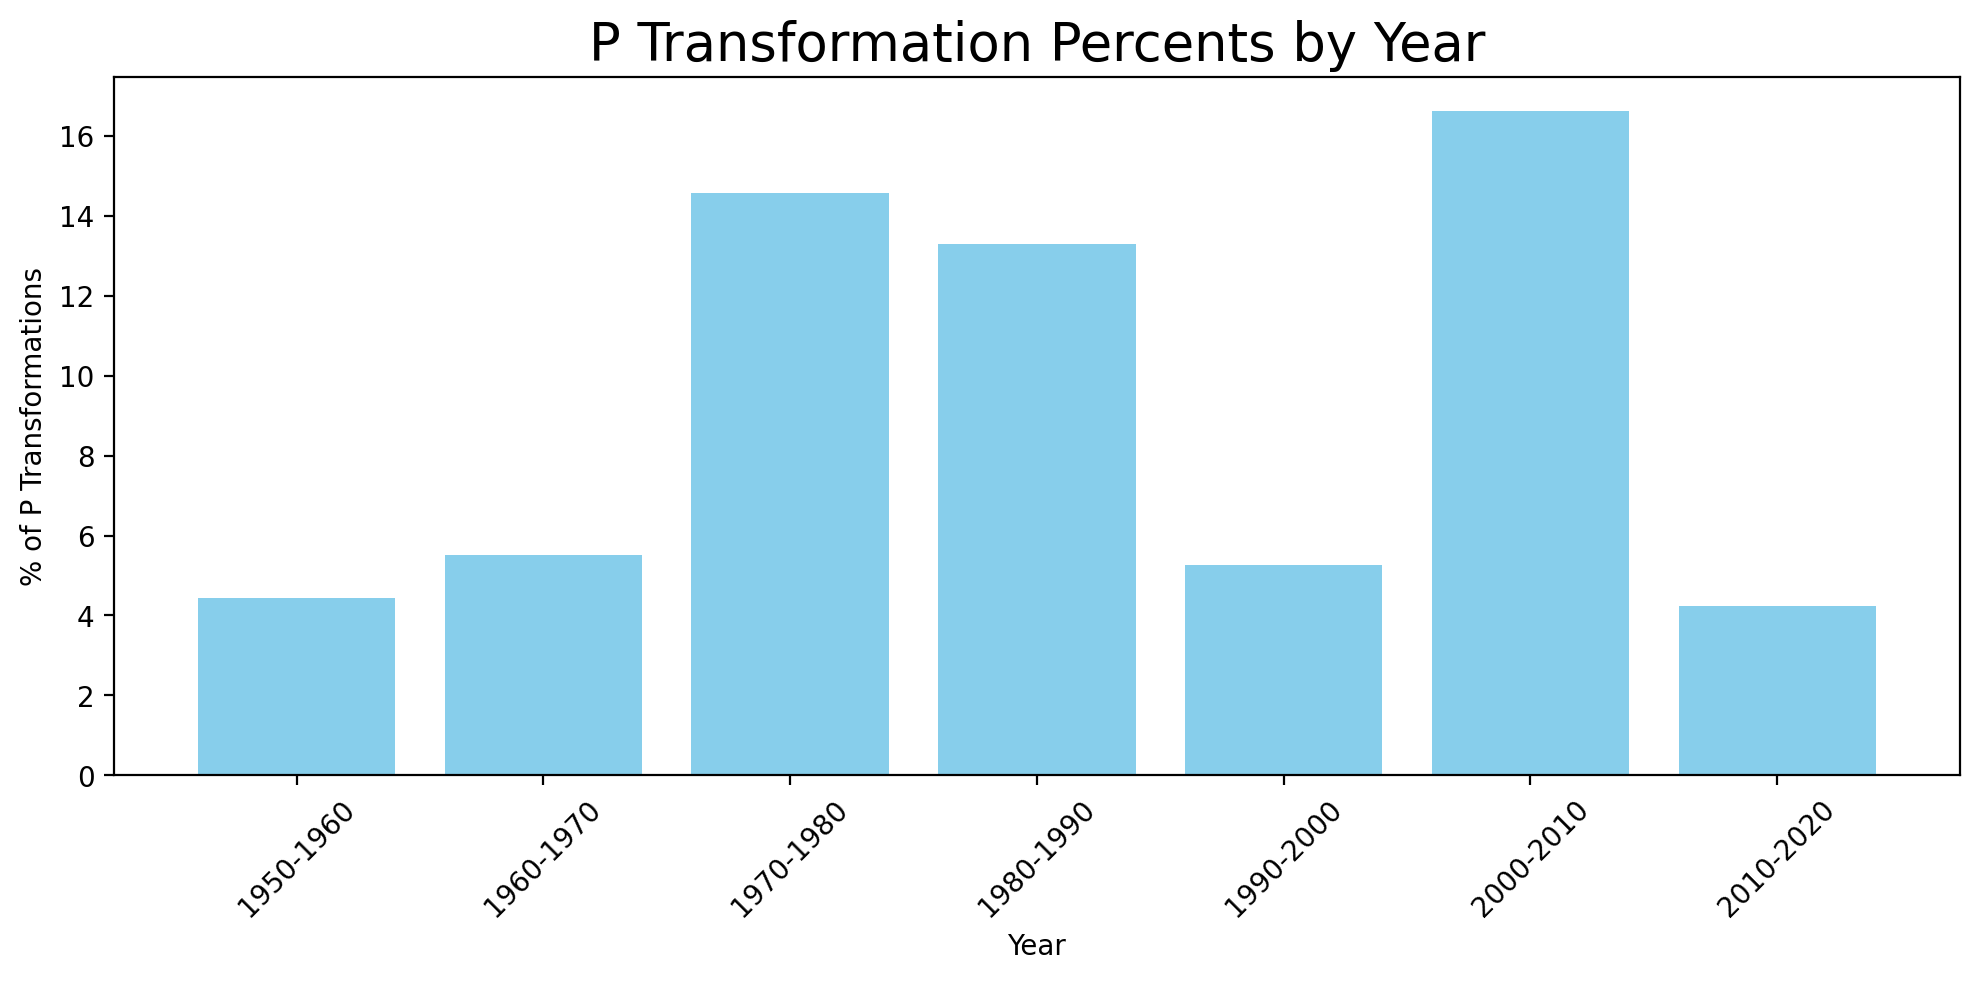

In [339]:
P, fig, ax = t.plot_transformation(transformations_cut, 'P')
plt.tight_layout()
#plt.savefig(f"../Results/PTransformation")
plt.show()

/Users/Jessica/Documents/ERIP2025/Jessica-ERIP2025/Importables/tonnetz_utils.py:396: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.


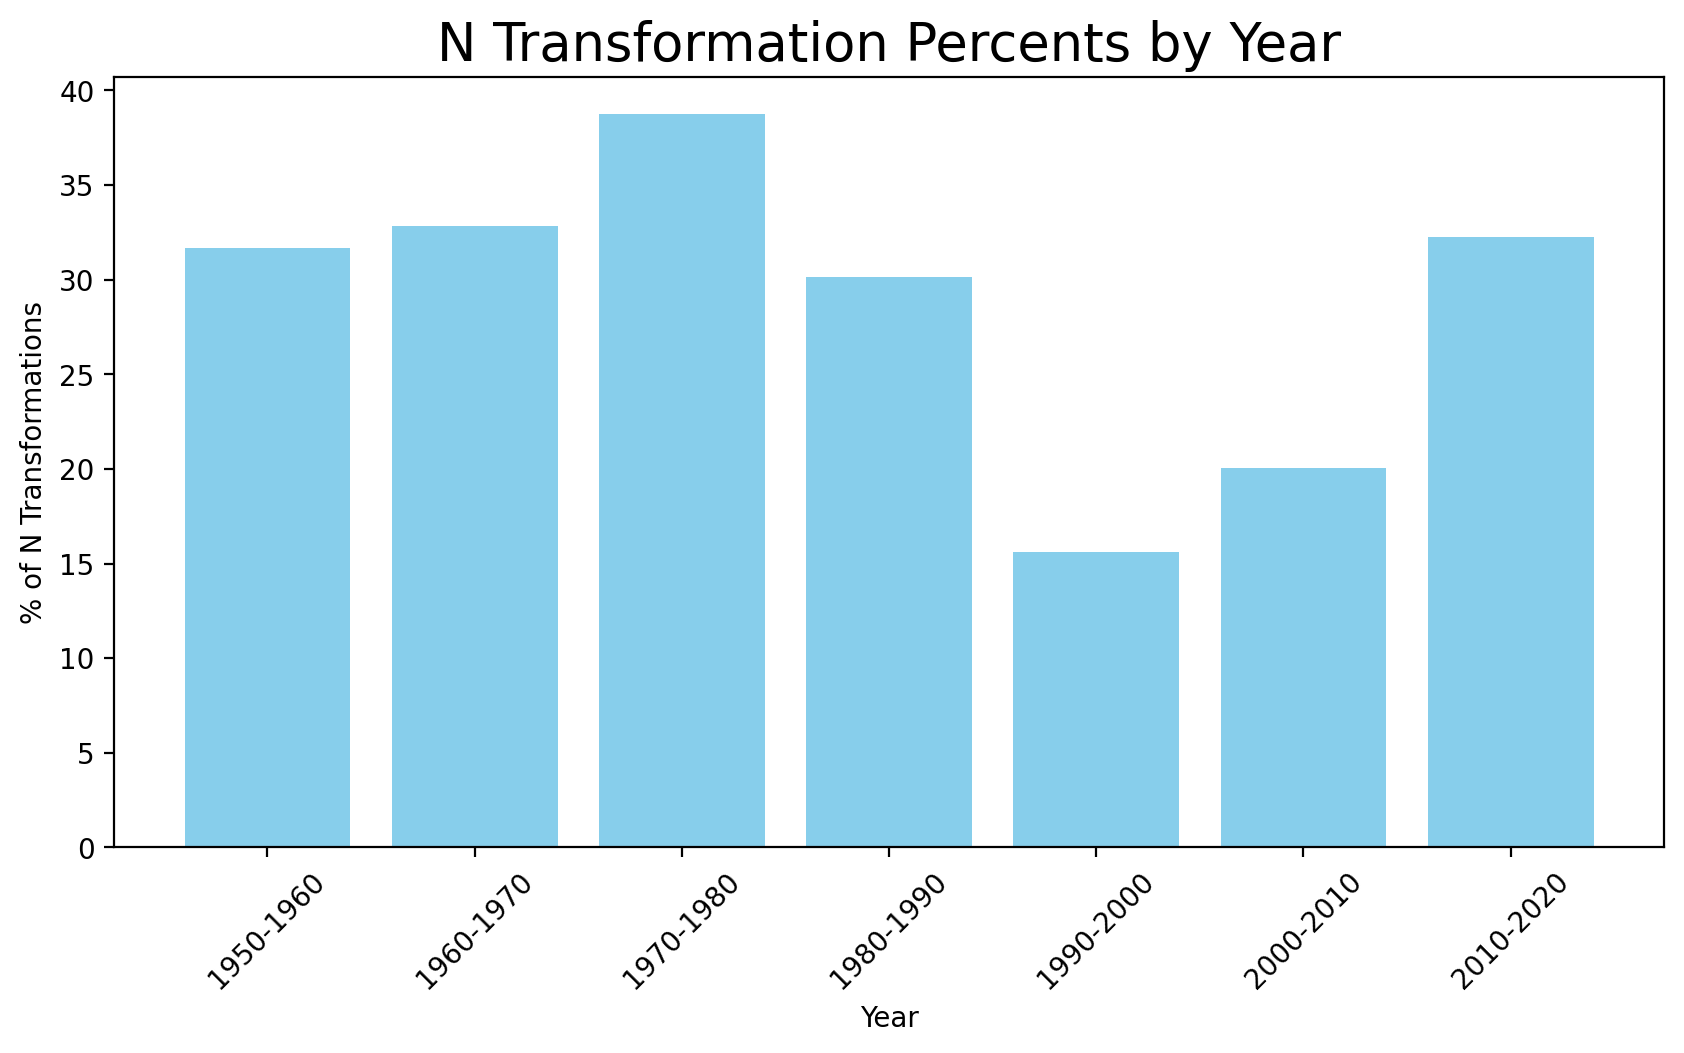

In [341]:
N, fig, ax = t.plot_transformation(transformations_cut, 'N')

/Users/Jessica/Documents/ERIP2025/Jessica-ERIP2025/Importables/tonnetz_utils.py:396: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.


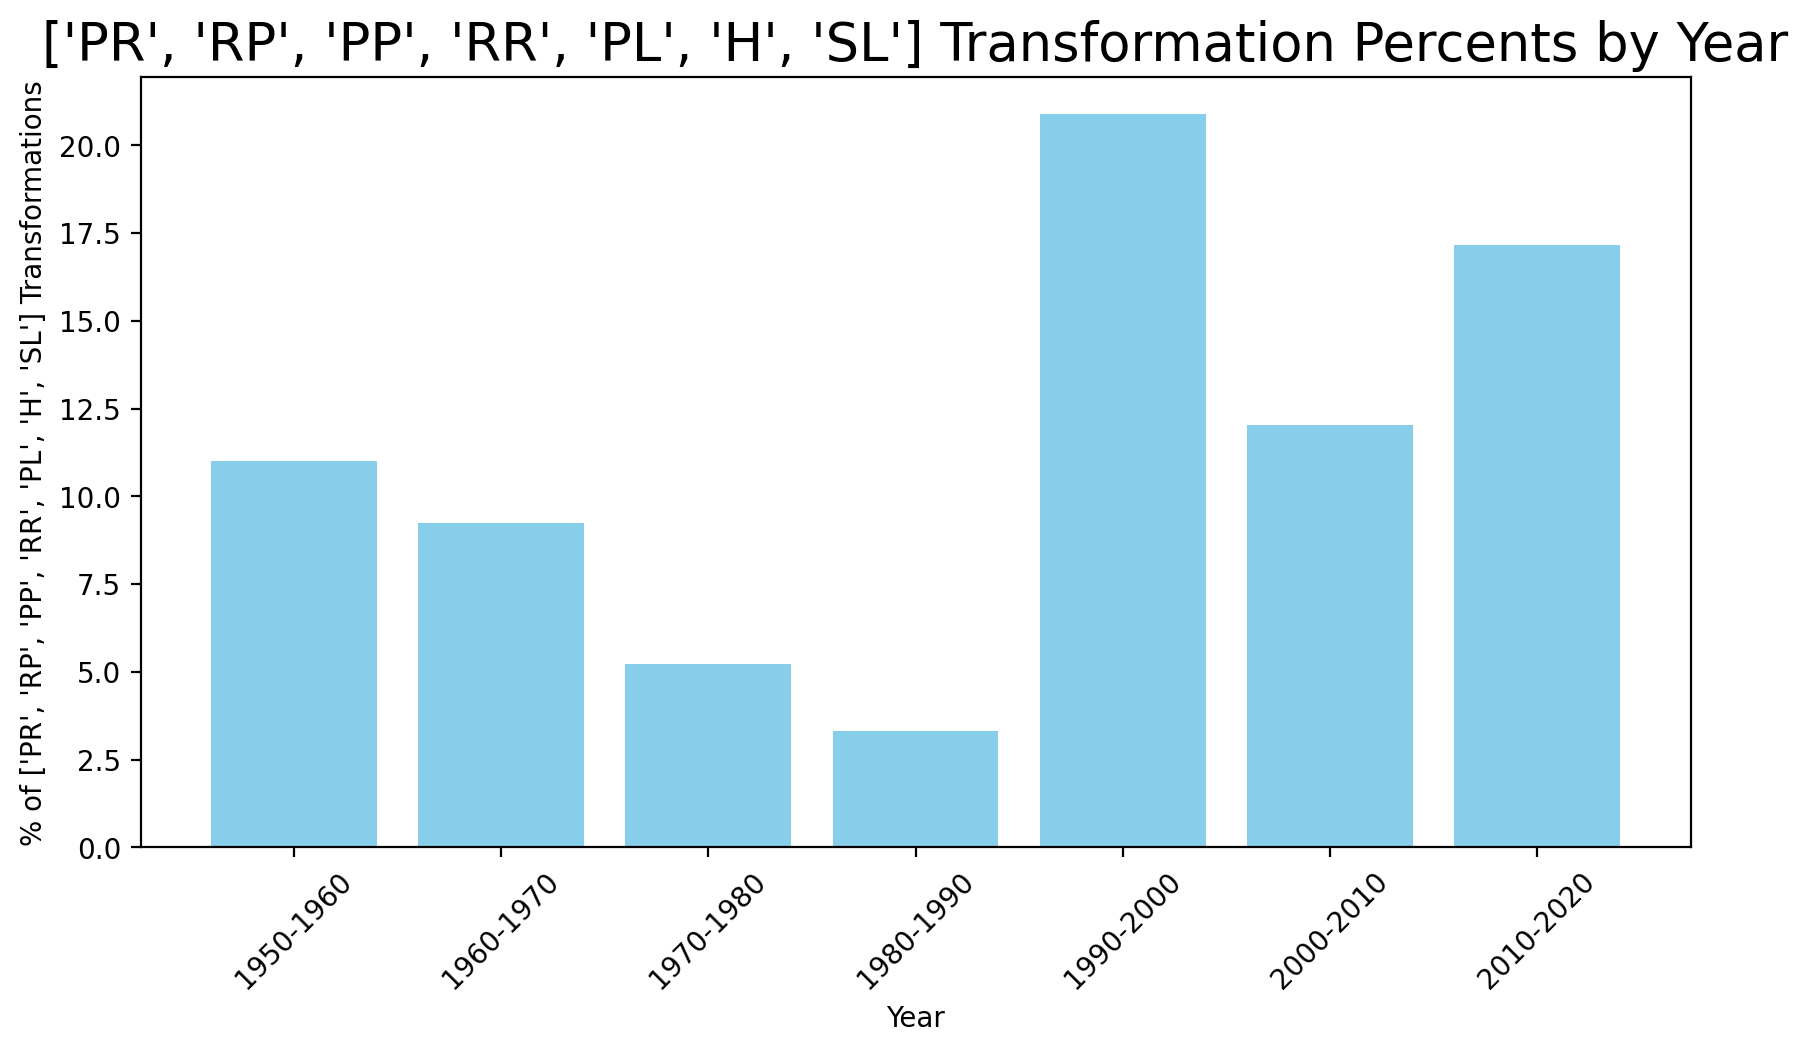

In [343]:
RPL, fig, ax = t.plot_transformation(transformations_cut, ['PR', 'RP', 'PP', 'RR', 'PL', 'H', 'S' 'L'])

/Users/Jessica/Documents/ERIP2025/Jessica-ERIP2025/Importables/tonnetz_utils.py:396: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.


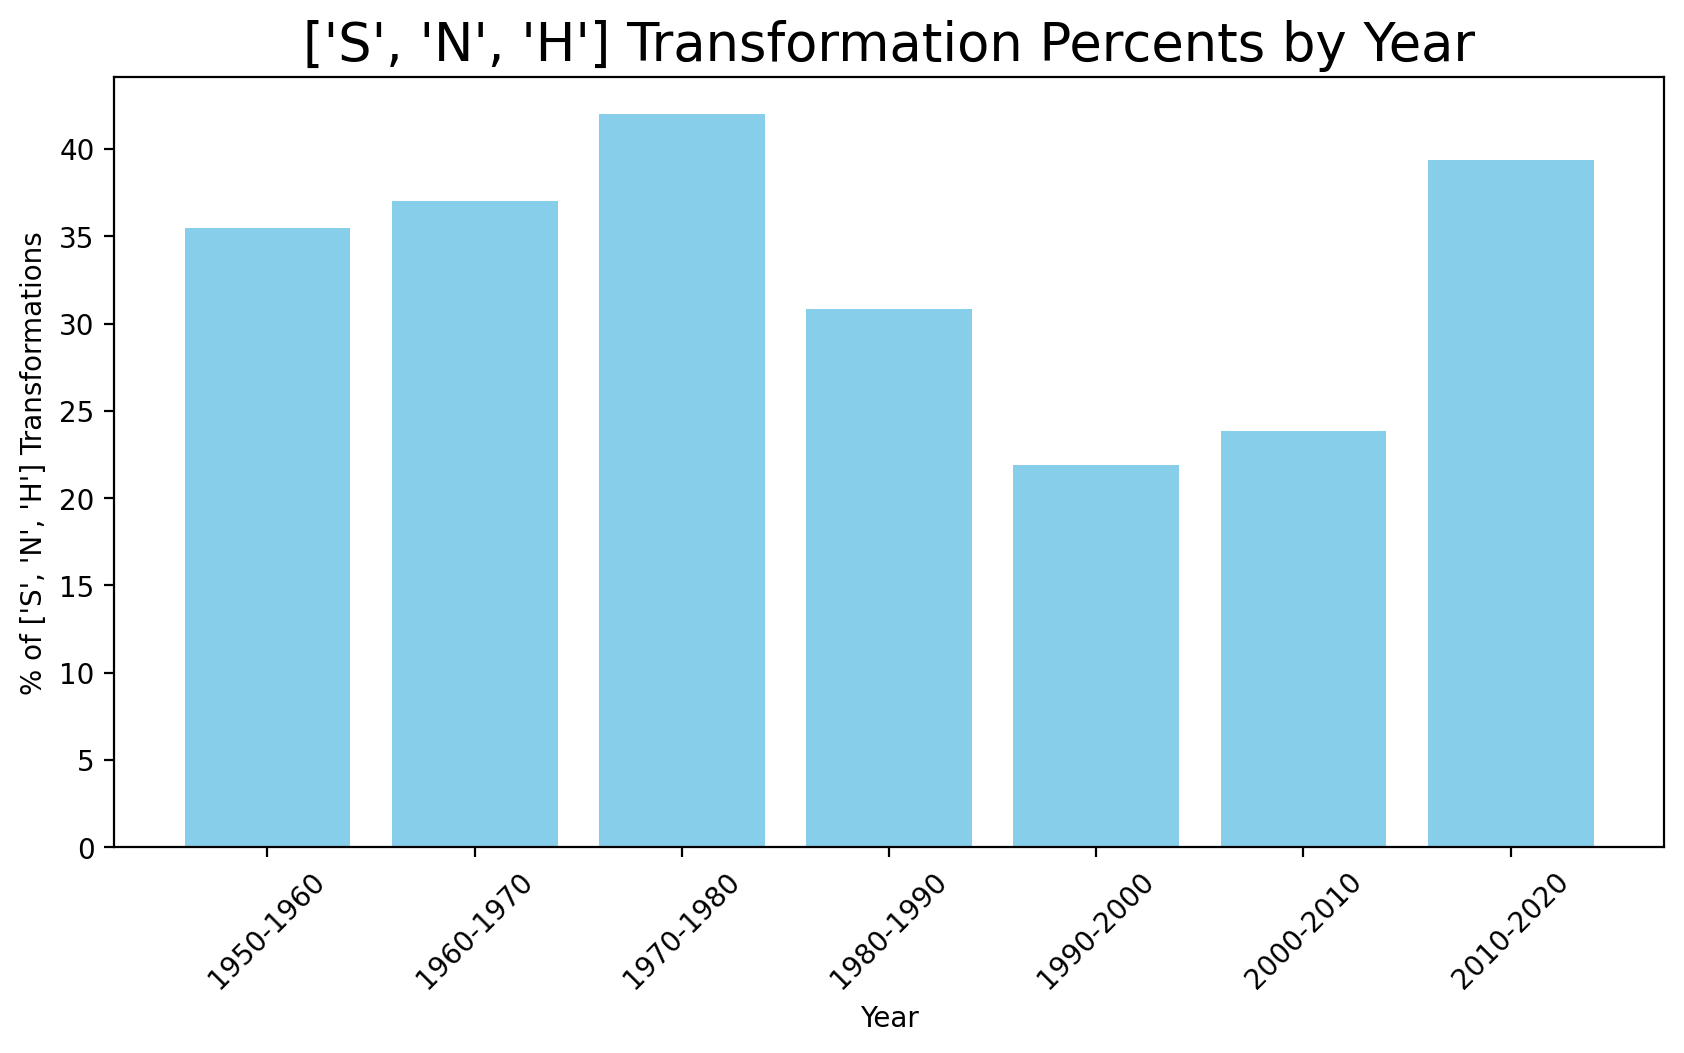

In [345]:
SNH, fig, ax = t.plot_transformation(transformations_cut, ['S','N','H'])

## Group by artist

1. Calculate the average % of each transformation globally (# transformation x / total transformations)
2. Calculate the average % of each transformation for each artist (# transformation x for artist y / total transformations for artist y)

In [276]:
list_transformations = transformations_cut['transformation'].unique()

In [277]:
average_percentages=[]
tot_count = transformations_cut.shape[0]

for t in list_transformations:
    # bootstrap
    sample_mean = []
    for i in range(100):
        sub_samp = transformations_cut.sample(frac=1, replace=True)
        t_count = sub_samp[sub_samp['transformation'] == t].shape[0]
            
        avg = 100 * t_count / tot_count
        sample_mean.append(avg)

    average_percentages.append(sample_mean)
    

#### Picking top artists by % transformation for each artist normalized per tot transformation per artist

In [279]:
artists_labels = []
tot_count = transformations_cut['artist'].value_counts()
for t in list_transformations:
    subset = transformations[transformations['transformation'] == t]
    grouped_artists = subset['artist'].value_counts()

    artist_percentages = (grouped_artists / tot_count[grouped_artists.index]) * 100
    top_artists = artist_percentages.sort_values(ascending=False).head(3)
    for a in top_artists.index:
        if a not in artists_labels:
            artists_labels.append(a)

In [280]:
transformations_artists = transformations.copy()
    
#pattern = '|'.join(re.escape(artist) for artist in artists_labels)
# transformations_artists['artist'] = transformations_artists['artist'].where(transformations_artists['artist'].str.contains(pattern, na=False), 'Other')
transformations_artists['artist'] = transformations_artists['artist'].where(transformations_artists['artist'].isin(artists_labels), 'Other')
transformations_artists_cut = transformations_artists[transformations_artists['transformation'] != 'N/A']


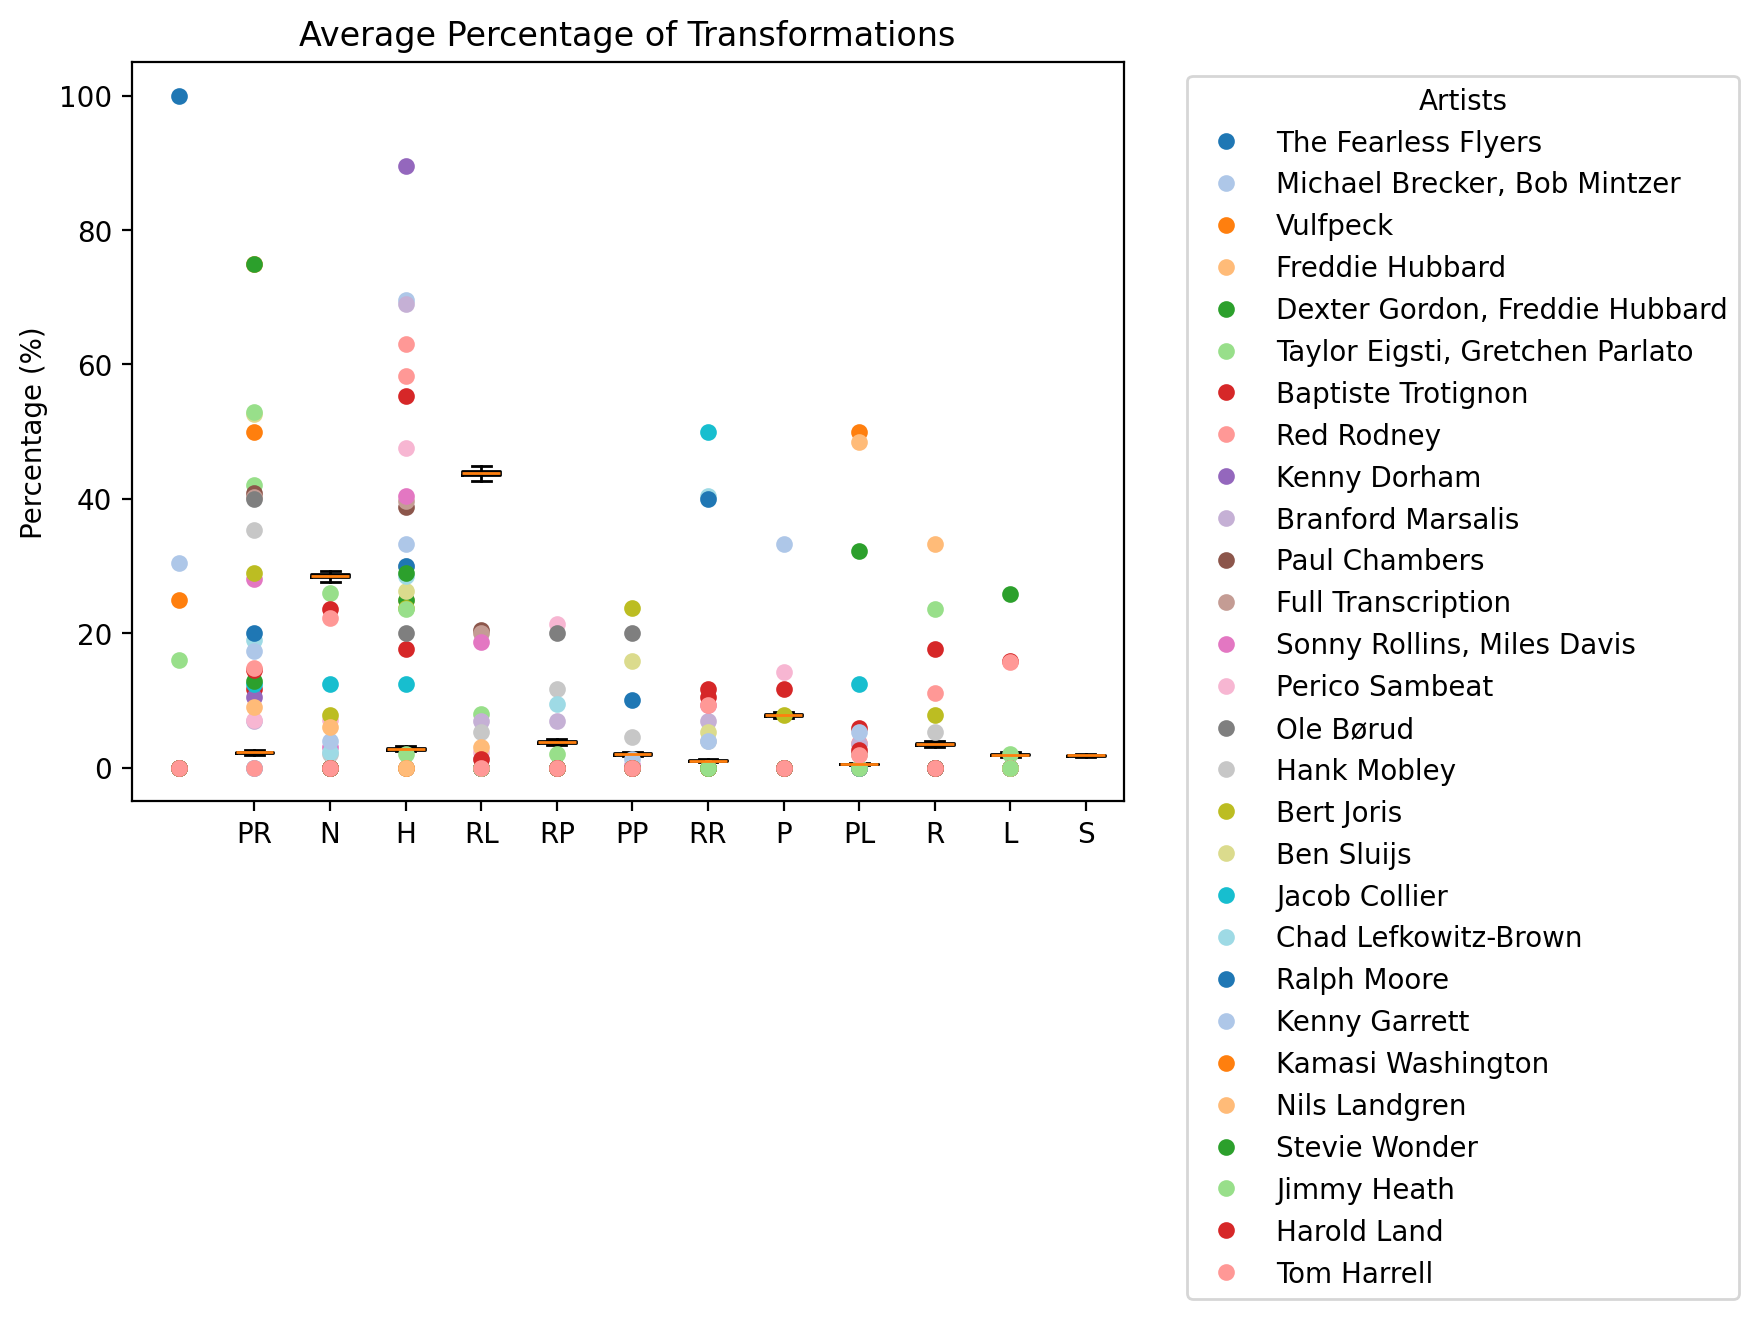

In [281]:
average_percentages_artists=[]

for t in list_transformations:
    t_avg = []
    for a in artists_labels:
        sub_samp = transformations_artists_cut[transformations_artists_cut['artist'] == a]
        # relative
        tot_count = sub_samp.shape[0]
        t_count = sub_samp[sub_samp['transformation'] == t].shape[0]

        if tot_count == 0:
            avg = 0  
        else:
            avg = 100 * t_count / tot_count
            
        t_avg.append(avg)

    average_percentages_artists.append(t_avg)

plt.boxplot(average_percentages, labels=list_transformations, showfliers=False)

colors = plt.cm.tab20.colors

for j, artist in enumerate(artists_labels):
    x_vals = []
    y_vals = []
    for i, points in enumerate(average_percentages_artists):
        y = points[j]  # this artist’s point for this transformation
        x_vals.append(i)
        y_vals.append(y)
    plt.plot(x_vals, y_vals, 'o', label=artist, color=colors[j % len(colors)], markersize=5)
    
plt.ylabel('Percentage (%)')
plt.title('Average Percentage of Transformations')
plt.legend(title="Artists", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

#### Picking top artists by % transformation for each artist normalized per tot transformation per artist

In [283]:
artists_labels = []
for t in list_transformations:
    subset = transformations[transformations['transformation'] == t]
    grouped_artists = subset['artist'].value_counts()
    for a in grouped_artists.index[:5]:
        if a not in artists_labels:
            artists_labels.append(a)

In [284]:
transformations_artists = transformations.copy()
    
#pattern = '|'.join(re.escape(artist) for artist in artists_labels)
# transformations_artists['artist'] = transformations_artists['artist'].where(transformations_artists['artist'].str.contains(pattern, na=False), 'Other')
transformations_artists['artist'] = transformations_artists['artist'].where(transformations_artists['artist'].isin(artists_labels), 'Other')
transformations_artists_cut = transformations_artists[transformations_artists['transformation'] != 'N/A']


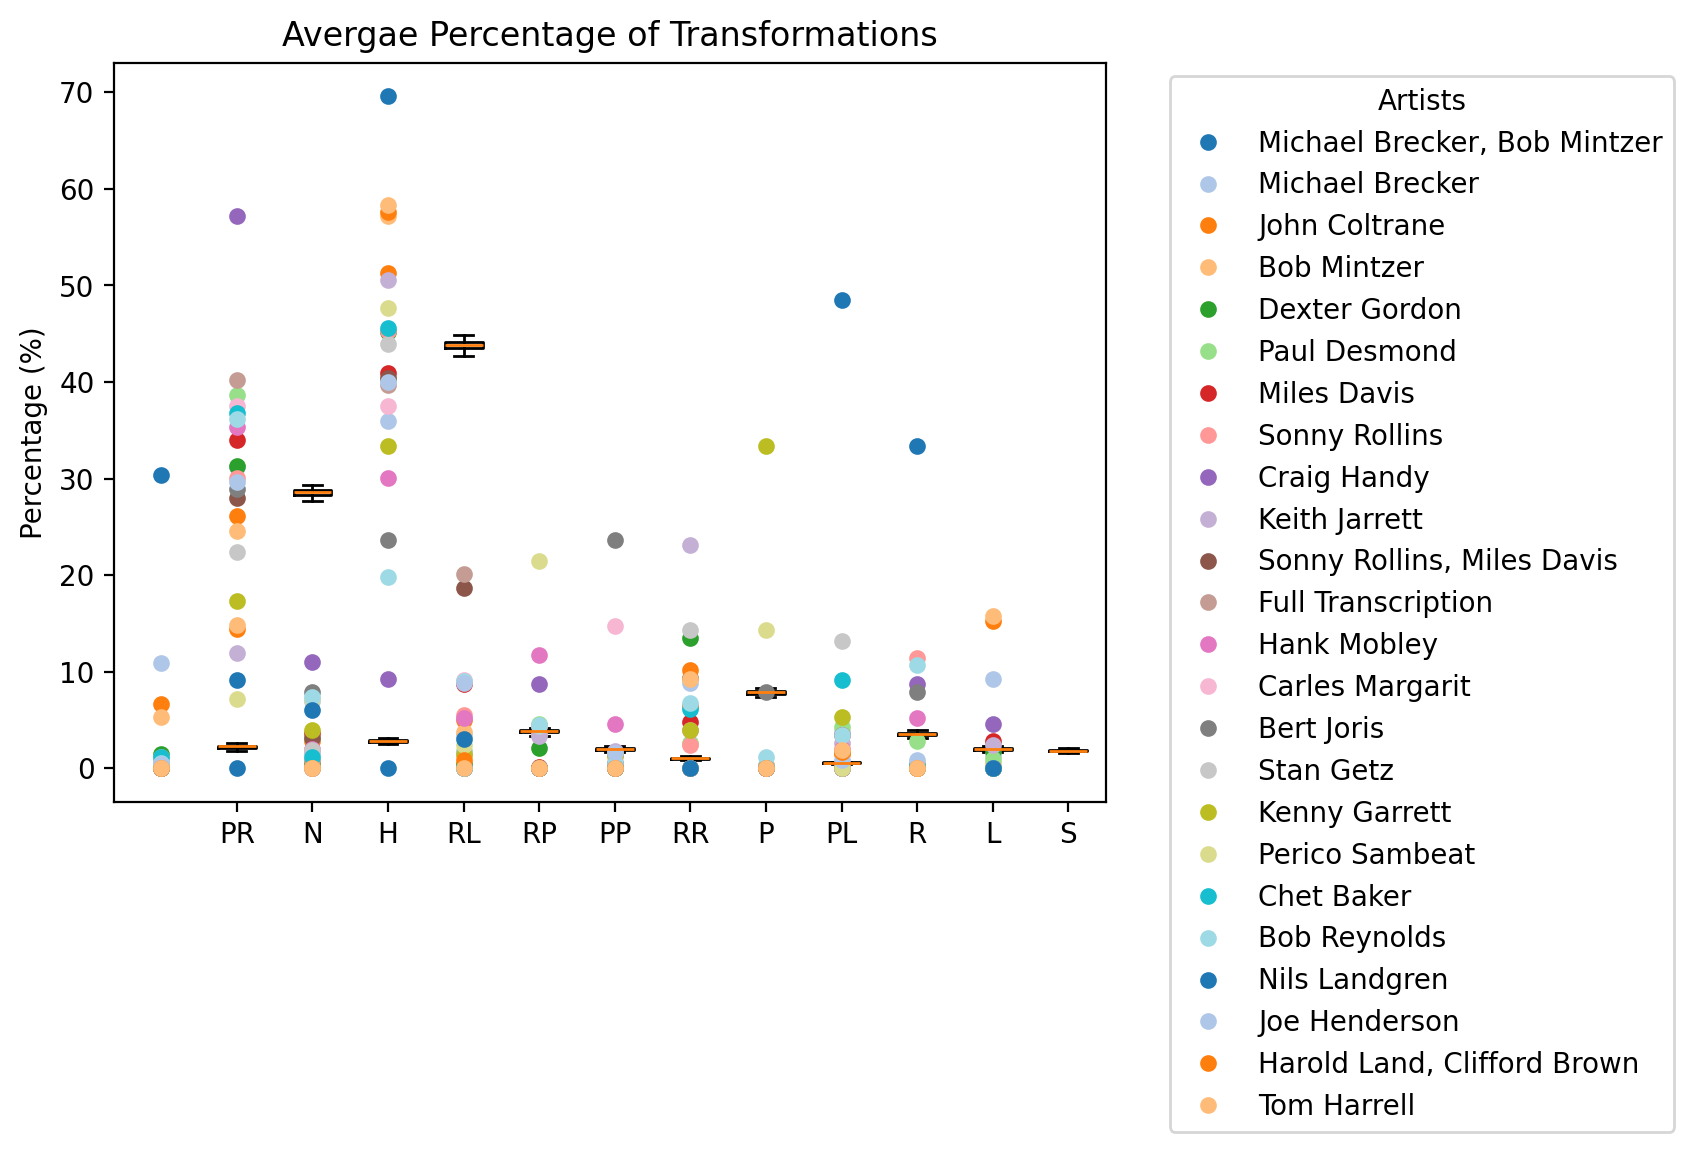

In [285]:
average_percentages_artists=[]

for t in list_transformations:
    t_avg = []
    for a in artists_labels:
        sub_samp = transformations_artists_cut[transformations_artists_cut['artist'] == a]
        tot_count = sub_samp.shape[0]
        t_count = sub_samp[sub_samp['transformation'] == t].shape[0]

        if tot_count == 0:
            avg = 0  
        else:
            avg = 100 * t_count / tot_count
            
        t_avg.append(avg)

    average_percentages_artists.append(t_avg)

plt.boxplot(average_percentages, labels=list_transformations, showfliers=False)

colors = plt.cm.tab20.colors

for j, artist in enumerate(artists_labels):
    x_vals = []
    y_vals = []
    for i, points in enumerate(average_percentages_artists):
        y = points[j]  # this artist’s point for this transformation
        x_vals.append(i)
        y_vals.append(y)
    plt.plot(x_vals, y_vals, 'o', label=artist, color=colors[j % len(colors)], markersize=5)
    
plt.ylabel('Percentage (%)')
plt.title('Avergae Percentage of Transformations')
plt.legend(title="Artists", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()